In [1]:
# import libraries
import qiskit
from qiskit import QuantumCircuit,transpile

from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.circuit.library import QFT
from qiskit.circuit import Parameter

from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.visualization import plot_histogram, plot_bloch_multivector


import matplotlib.pyplot as plt
import numpy as np 
from math import gcd 
from numpy.random import randint 
import pandas as pd 

In [25]:
## C = 1, A, B = max(v_i,j)

def knapsack_hamiltonian(weights, values, capacities):
    weights = np.array(weights); values = np.array(values); capacities = np.array(capacities)

    maxv = 2 * np.max(values)
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)


    gamma = Parameter("γ")

    qc = QuantumCircuit(n*m + total_s*m)

    for i in range(m): 
        b = np.array([_ for _ in range(s[i])])
        for j in range(n):
            # qubit i, j corresponds to i*n + j 
            # objective term 
            qc.rz(gamma*values[i], i*n + j)

            # occupation term 1 
            qc.rz(maxv * gamma*(1-2*m), i*n + j)

            # all capacity terms 
            cap_linear_ij = -np.sum(weights*weights[j])/2 - np.sum(weights[j]*2**b[i])/2 + weights[j]*capacities[i]
            qc.rz(maxv * 2*cap_linear_ij*gamma, i*n + j)

            for jp in range(n): 
                if j != jp: 
                    qc.rzz(maxv * gamma*weights[j]*weights[jp]/2, i*n + j, i*n + jp)

            for ip in range(m): 
                # occupation term 2 
                if i != ip: 
                    qc.rzz(maxv * gamma/2, i*n + j, ip*n + j)

            for b_val in b: 
                qc.rzz(maxv * gamma*weights[j]*2**b_val, i*n + j, n*m + i*s[i] + b_val)
        
        for b_val in b: 
            cap_linear_ib = -np.sum(2**(b_val+b[i]))/2 - np.sum(weights*2**b_val)/2 + 2**b_val*capacities[i]
            qc.rz(maxv * 2*cap_linear_ib*gamma, n*m + i*s[i] + b_val)

            for bp_val in b:
                if b_val != bp_val: 
                    qc.rzz(maxv * 2**(b_val + bp_val)/2, n*m + i*s[i] + b_val, n*m + i*s[i] + bp_val)

    return qc 

In [29]:
def mixing_hamiltonian(N): 
    beta = Parameter("β")
    qc = QuantumCircuit(N)
    
    for i in range(N): 
        qc.rx(2*beta, i)

    return qc 

In [ ]:
def full_knapsack_circuit(weights, values, capacities): 
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)
    N = n*m + total_s*m

    qc = QuantumCircuit(N)
    qc.h(range(N))

    qc = qc.compose(knapsack_hamiltonian(weights, values, capacities))
    qc = qc.compose(mixing_hamiltonian(N))

    qc.draw("mpl")
    return qc 

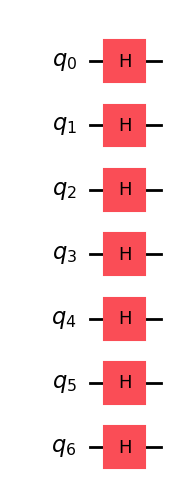

In [34]:
capacities = [10]
weights = [2, 5, 3]
values = [1, 8, 10]

mycirc = full_knapsack_circuit(weights, values, capacities)
mycirc.draw("mpl")